In [11]:
import polars as pl
from tcrtrifold.utils import FORMAT_TCR_COLS, TCRDIST_COLS, FORMAT_ANTIGEN_COLS
from tcrtrifold.tcrdist_utils import pw_tcrdist

cresta = pl.read_parquet("../../data/cresta/triad/cresta_triad.conf_af3.parquet")
cresta_tcrs = cresta.select(FORMAT_TCR_COLS + TCRDIST_COLS).unique()

In [3]:
tcr_indices, tcr_dists = pw_tcrdist(cresta_tcrs)

/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/tcrdist/repertoire.py:159: UserWarning: cell_df needs a column called 'v_a_gene' for default functions

  self._validate_cell_df()
/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/tcrdist/repertoire.py:159: UserWarning: cell_df needs a column called 'v_b_gene' for default functions

  self._validate_cell_df()


In [96]:
import sklearn.metrics as metrics
import numpy as np


# triad_dataset = cresta.with_columns(
#     ((31 - pl.col("mean_p_tcr_pae")) / 31).alias("mean_p_tcr_pae")
# )
# grouping_cols = FORMAT_ANTIGEN_COLS
# featname = "mean_p_tcr_pae"
# tcrdist_thresh = 120


def antigen_score_with_tcrdist(
    triad_dataset,
    featname,
    grouping_cols=FORMAT_ANTIGEN_COLS,
    tcrdist_thresh=120,
    train_proportion=0.2,
    testing=False,
):

    antigens = triad_dataset.select(grouping_cols).unique(maintain_order=True)

    out_df = []

    for row in antigens.iter_rows(named=True):
        antigen = pl.DataFrame([row]).select(pl.exclude("job_name"))

        focal_antigen_triads = triad_dataset.join(
            antigen, on=grouping_cols, nulls_equal=True, maintain_order="left"
        ).sample(fraction=1, shuffle=True, seed=42)

        train_size = int(focal_antigen_triads.height * train_proportion)
        train, test = focal_antigen_triads.head(train_size), focal_antigen_triads.tail(
            -train_size
        )

        train_pos = train.filter(pl.col("cognate"))
        train_pos_indices = (
            train_pos.select(FORMAT_TCR_COLS)
            .join(tcr_indices, on=FORMAT_TCR_COLS)
            .select("index")
            .to_series()
            .to_numpy()
        )

        test_with_indices = test.join(
            tcr_indices, on=FORMAT_TCR_COLS, maintain_order="left"
        )

        new_row = row.copy()

        dat = test_with_indices.select(featname, "cognate", "index").to_numpy()

        rows_below_thresh = (
            tcr_dists[dat[:, 2].astype(np.int32)][:, train_pos_indices] < tcrdist_thresh
        ).any(axis=1)

        if rows_below_thresh.any():
            print("help")

        if not testing:
            dat[:, 0][rows_below_thresh] = 1

        fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
        roc_auc = metrics.auc(fpr, tpr)
        new_row["roc_auc"] = roc_auc
        new_row["fpr"] = fpr.tolist()
        new_row["tpr"] = tpr.tolist()

        out_df.append(new_row)

    return pl.DataFrame(out_df)


def antigen_tcrdist(
    triad_dataset,
    grouping_cols=FORMAT_ANTIGEN_COLS,
    train_proportion=0.2,
):

    antigens = triad_dataset.select(grouping_cols).unique(maintain_order=True)

    out_df = []

    for row in antigens.iter_rows(named=True):
        antigen = pl.DataFrame([row]).select(pl.exclude("job_name"))

        focal_antigen_triads = triad_dataset.join(
            antigen, on=grouping_cols, nulls_equal=True, maintain_order="left"
        ).sample(fraction=1, shuffle=True, seed=42)

        train_size = int(focal_antigen_triads.height * train_proportion)
        train, test = focal_antigen_triads.head(train_size), focal_antigen_triads.tail(
            -train_size
        )

        train_pos = train.filter(pl.col("cognate"))
        train_pos_indices = (
            train_pos.select(FORMAT_TCR_COLS)
            .join(tcr_indices, on=FORMAT_TCR_COLS)
            .select("index")
            .to_series()
            .to_numpy()
        )

        test_with_indices = test.join(
            tcr_indices, on=FORMAT_TCR_COLS, maintain_order="left"
        )

        new_row = row.copy()

        dat = test_with_indices.select("cognate", "index").to_numpy()

        min_dist_from_cognate = (
            tcr_dists[dat[:, 1].astype(np.int32)][:, train_pos_indices]
        ).min(axis=1)

        print(row["peptide"])
        print(min_dist_from_cognate.min())

        fpr, tpr, threshold = metrics.roc_curve(dat[:, 0], 1 - min_dist_from_cognate)
        roc_auc = metrics.auc(fpr, tpr)
        new_row["roc_auc"] = roc_auc
        new_row["fpr"] = fpr.tolist()
        new_row["tpr"] = tpr.tolist()

        out_df.append(new_row)

    return pl.DataFrame(out_df)

help
help
help
help
help


<Axes: title={'center': 'CRESTA AUC, p(cognate)= 1 if tcrdist from training tcr < 120,\n else mean p:TCR PAE (train % = 20)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

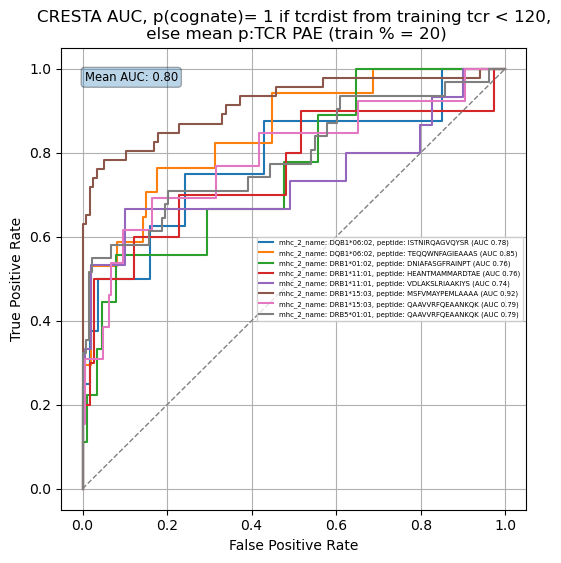

In [103]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

cresta_auc = antigen_score_with_tcrdist(
    cresta.with_columns(((31 - pl.col("mean_p_tcr_pae")) / 31).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(
    cresta_auc,
    id_cols=["mhc_2_name", "peptide"],
    title="CRESTA AUC, p(cognate)= 1 if tcrdist from training tcr < 120,\n else mean p:TCR PAE (train % = 20)",
)

help
help
help
help
help


<Axes: title={'center': 'CRESTA AUC, p(cognate)= mean p:TCR PAE'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

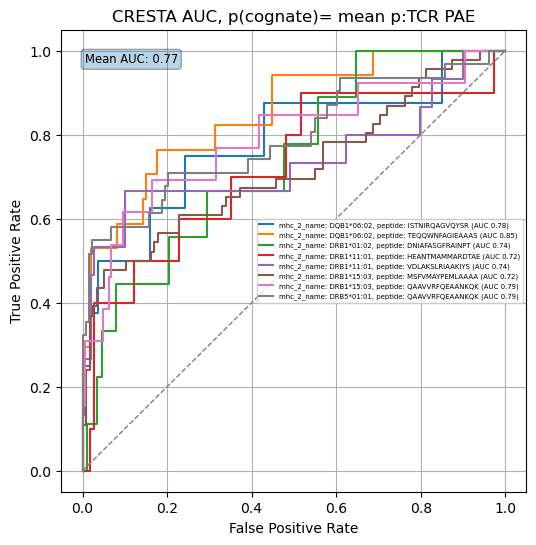

In [101]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

cresta_auc = antigen_score_with_tcrdist(
    cresta.with_columns(((31 - pl.col("mean_p_tcr_pae")) / 31).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    testing=True,
)

plot_auc_per_antigen(
    cresta_auc,
    id_cols=["mhc_2_name", "peptide"],
    title="CRESTA AUC, p(cognate)= mean p:TCR PAE",
)

QAAVVRFQEAANKQK
189
VDLAKSLRIAAKIYS
108
MSFVMAYPEMLAAAA
24
QAAVVRFQEAANKQK
81
DNIAFASGFRAINPT
96
HEANTMAMMARDTAE
45
ISTNIRQAGVQYSR
151
TEQQWNFAGIEAAAS
134


<Axes: title={'center': 'CRESTA AUC, p(cognate)= min TCRdist to training cognate TCRs (train % = 20)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

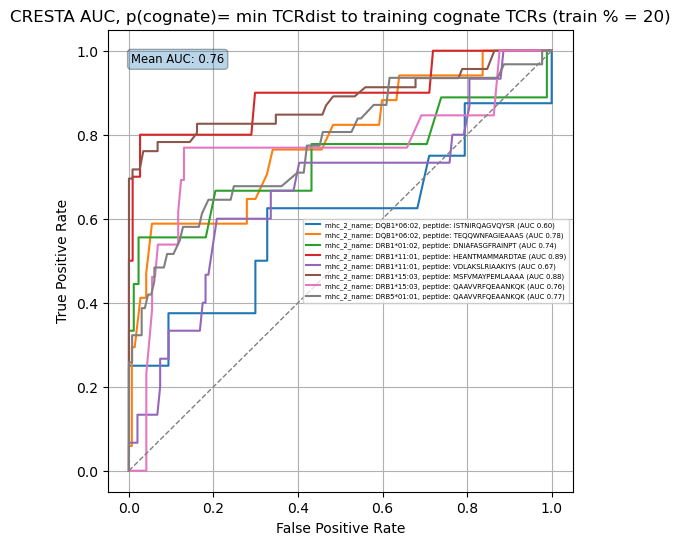

In [99]:
from tcrtrifold.viz_utils import plot_auc_per_antigen

cresta_auc = antigen_tcrdist(cresta, train_proportion=0.2)

plot_auc_per_antigen(
    cresta_auc,
    id_cols=["mhc_2_name", "peptide"],
    title="CRESTA AUC, p(cognate)= min TCRdist to training cognate TCRs (train % = 20)",
)